In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

In [7]:
df = pd.read_csv("../data/drug_discovery_virtual_screening.csv")
# df = df.drop("Unnamed: 0", axis=1)


In [12]:
df['protein_id'].value_counts()

protein_id
PID_131    11
PID_170    11
PID_125    10
PID_288    10
PID_237    10
           ..
PID_469     1
PID_423     1
PID_488     1
PID_143     1
PID_281     1
Name: count, Length: 400, dtype: int64

In [13]:
df[df['protein_id'] == "PID_170"]

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
83,CID_00083,PID_170,398.172978,0.055729,2,9,6,75.610244,1.507370,315,5.687165,0.616042,17.669424,1.264041,0.316938,4.778317,0
232,CID_00232,PID_170,454.557184,0.544844,4,10,7,98.052847,4.528891,852,4.511350,0.671554,20.253551,0.533518,2.457983,4.229331,0
251,CID_00251,PID_170,541.786195,5.766732,1,7,8,83.081307,-0.939139,1197,8.081775,0.564998,11.874890,0.452620,46.605432,8.066147,1
335,CID_00335,PID_170,435.294262,4.362808,0,6,7,83.443277,2.212231,754,7.295129,0.423372,14.680066,0.577313,31.827242,7.164864,1
493,CID_00493,PID_170,363.871580,5.665448,3,6,5,79.910970,2.038442,1336,8.329196,0.723462,15.322348,0.272359,47.188629,8.625224,1
672,CID_00672,PID_170,415.731241,3.890663,1,8,4,NaN,2.027612,400,7.452245,NaN,17.056527,1.039328,28.994177,6.837756,0
762,CID_00762,PID_170,706.008454,4.843033,3,2,5,107.914059,3.681169,1431,7.069725,0.728868,8.760632,0.493367,34.238914,7.626888,1
1044,CID_01044,PID_170,432.737270,4.571915,3,6,7,94.026534,1.963259,920,7.616123,0.758956,16.421568,0.470367,34.820263,7.835804,1
1306,CID_01306,PID_170,452.818116,4.298009,0,3,7,114.631565,2.607672,297,6.582112,0.711852,13.303714,1.524640,28.289977,6.731089,0
1450,CID_01450,PID_170,480.883301,2.783532,3,3,3,83.047829,0.842249,430,5.941539,NaN,18.224886,1.118333,16.538460,5.405550,0


In [265]:
# get rid of the thing that's already an interaction term
df = df.drop(["logp_pi_interaction"], axis=1)

In [266]:
X = df.drop(['active'], axis=1)
y = df['active']

In [267]:
poly = PolynomialFeatures(2, interaction_only=False)
Xe = poly.fit_transform(X)
cols = poly.get_feature_names_out(X.columns)
Xe = pd.DataFrame(Xe, columns=cols)
# Xe = Xe.drop(['1'], axis=1)
Xe

,1,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,...,protein_pi^2,protein_pi hydrophobicity,protein_pi binding_site_size,protein_pi mw_ratio,hydrophobicity^2,hydrophobicity binding_site_size,hydrophobicity mw_ratio,binding_site_size^2,binding_site_size mw_ratio,mw_ratio^2
0,1.0,499.671415,2.487233,1.0,7.0,4.0,113.350817,4.050696,678.0,6.019657,...,36.236273,4.891176,75.318947,4.436358,0.660212,10.166560,0.598820,156.554283,9.221197,0.543137
1,1.0,436.173570,3.283222,3.0,4.0,4.0,71.981132,3.704408,876.0,6.447408,...,41.569068,4.199948,74.392901,3.210261,0.424343,7.516318,0.324350,133.135143,5.745153,0.247919
2,1.0,514.768854,3.479480,2.0,11.0,11.0,83.936307,1.869610,658.0,3.925837,...,15.412192,2.486889,51.647134,3.071274,0.401281,8.333706,0.495576,173.072490,10.292015,0.612030
3,1.0,602.302986,3.038058,0.0,5.0,5.0,79.868125,2.451909,312.0,7.597056,...,57.715254,3.897580,91.710306,14.665799,0.263208,6.193307,0.990399,145.728897,23.304150,3.726669
4,1.0,426.584663,0.659578,2.0,4.0,5.0,88.198676,1.771936,1418.0,4.249454,...,18.057857,2.607343,67.355743,1.278386,0.376470,9.725380,0.184584,251.236689,4.768376,0.090502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,1.0,557.015024,3.542686,4.0,5.0,11.0,102.329688,1.470121,240.0,7.862185,...,61.813957,6.061159,167.534590,18.247314,0.594326,16.427581,1.789238,454.069604,49.455760,5.386558
1995,1.0,447.347874,0.383282,1.0,8.0,5.0,52.321214,3.739447,718.0,7.401501,...,54.782214,4.771902,122.706949,4.611484,0.415665,10.688608,0.401692,274.851894,10.329286,0.388188
1996,1.0,361.812535,3.019553,0.0,4.0,9.0,86.722469,3.122027,1228.0,5.551238,...,30.816242,3.980482,93.425949,1.635592,0.514152,12.067672,0.211267,283.240508,4.958644,0.086810
1997,1.0,433.693304,5.965067,0.0,4.0,10.0,86.932238,3.866579,1244.0,5.680128,...,32.263858,3.755955,60.233180,1.980252,0.437245,7.011967,0.230528,112.448921,3.696919,0.121542


In [268]:
Xe_train, Xe_test, y_train, y_test = train_test_split(Xe, y, test_size=0.2, train_size=0.8, stratify=y, random_state=8123)

In [269]:
grid = {"n_estimators" : np.arange(10, 200, 10), "max_depth": np.arange(1, 20, 2)}

In [225]:
rfc = RandomForestClassifier()
rfcCV = GridSearchCV(rfc, param_grid=grid, verbose=3)

In [270]:
rfcCV.fit(Xe_train, y_train)

Fitting 5 folds for each of 190 candidates, totalling 950 fits
[CV 1/5] END ......max_depth=1, n_estimators=10;, score=0.756 total time=   0.0s
[CV 2/5] END ......max_depth=1, n_estimators=10;, score=0.834 total time=   0.0s
[CV 3/5] END ......max_depth=1, n_estimators=10;, score=0.806 total time=   0.0s
[CV 4/5] END ......max_depth=1, n_estimators=10;, score=0.725 total time=   0.0s
[CV 5/5] END ......max_depth=1, n_estimators=10;, score=0.850 total time=   0.0s
[CV 1/5] END ......max_depth=1, n_estimators=20;, score=0.734 total time=   0.0s
[CV 2/5] END ......max_depth=1, n_estimators=20;, score=0.838 total time=   0.0s
[CV 3/5] END ......max_depth=1, n_estimators=20;, score=0.831 total time=   0.0s
[CV 4/5] END ......max_depth=1, n_estimators=20;, score=0.694 total time=   0.0s
[CV 5/5] END ......max_depth=1, n_estimators=20;, score=0.799 total time=   0.0s
[CV 1/5] END ......max_depth=1, n_estimators=30;, score=0.844 total time=   0.0s
[CV 2/5] END ......max_depth=1, n_estimators=3

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 1, 3..., 15, 17, 19]), 'n_estimators': array([ 10, ...70, 180, 190])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

In [271]:
y_pred = rfcCV.predict(Xe_test)
y_prob = rfcCV.predict_proba(Xe_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Random Forest Accuracy:", accuracy)
print("Random Forest ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.8825
Random Forest ROC-AUC: 0.9297971458898455

Confusion Matrix:
[[260  18]
 [ 29  93]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.94      0.92       278
         1.0       0.84      0.76      0.80       122

    accuracy                           0.88       400
   macro avg       0.87      0.85      0.86       400
weighted avg       0.88      0.88      0.88       400



In [272]:
grid = {'max_depth': np.arange(1, 30)}

tree = DecisionTreeClassifier()
treeCV = GridSearchCV(tree, param_grid=grid, n_jobs=-1, verbose=3)
treeCV.fit(Xe_train, y_train)

Fitting 5 folds for each of 29 candidates, totalling 145 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 1, 2..., 27, 28, 29])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [273]:
depth = treeCV.best_params_['max_depth']
tree = DecisionTreeClassifier(max_depth=depth)
tree.fit(Xe_train, y_train)

y_pred = tree.predict(Xe_test)
y_prob = tree.predict_proba(Xe_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Decision Tree Accuracy:", accuracy)
print("Decision Tree ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.8975
Decision Tree ROC-AUC: 0.8991478947989149

Confusion Matrix:
[[266  12]
 [ 29  93]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93       278
         1.0       0.89      0.76      0.82       122

    accuracy                           0.90       400
   macro avg       0.89      0.86      0.87       400
weighted avg       0.90      0.90      0.90       400



[Text(0.5, 0.8333333333333334, 'logp protein_pi <= 29.002\ngini = 0.423\nsamples = 1599\nvalue = [1113.0, 486.0]'),
 Text(0.25, 0.5, 'logp protein_pi <= 24.319\ngini = 0.182\nsamples = 1177\nvalue = [1058.0, 119.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.079\nsamples = 947\nvalue = [908, 39]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.454\nsamples = 230\nvalue = [150, 80]'),
 Text(0.75, 0.5, 'logp hydrophobicity <= 5.588\ngini = 0.227\nsamples = 422\nvalue = [55.0, 367.0]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.209\nsamples = 414\nvalue = [49, 365]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.375\nsamples = 8\nvalue = [6, 2]')]

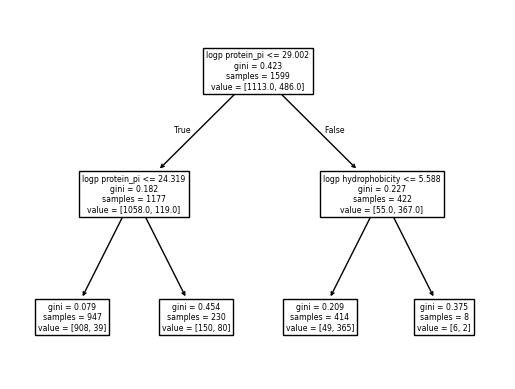

In [231]:
plot_tree(tree, feature_names=Xe.columns)

In [274]:
grid = {'learning_rate': [0.005, 0.01, 0.015], 'n_estimators': np.arange(50, 70, 1), 'max_depth': np.arange(1,3)}

In [275]:
gbt = GradientBoostingClassifier()
gbtCV = GridSearchCV(gbt, param_grid=grid, n_jobs=-1, verbose=3, return_train_score=True)
gbtCV.fit(Xe_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.005, 0.01, ...], 'max_depth': array([1, 2]), 'n_estimators': array([50, 51... 67, 68, 69])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [276]:
print("Gradient Boosing Trees:")
print("Optimal hyperparameters:", gbtCV.best_params_)
print("Optimal Valid R2 =", gbtCV.best_score_)

Gradient Boosing Trees:
Optimal hyperparameters: {'learning_rate': 0.01, 'max_depth': np.int64(2), 'n_estimators': np.int64(58)}
Optimal Valid R2 = 0.8892985893416929


In [277]:
y_pred = gbtCV.predict(Xe_test)
y_prob = gbtCV.predict_proba(Xe_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Gradient Boosting Accuracy:", accuracy)
print("Gradient Boosting ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Gradient Boosting Accuracy: 0.8925
Gradient Boosting ROC-AUC: 0.9148042221960136

Confusion Matrix:
[[267  11]
 [ 32  90]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.93       278
         1.0       0.89      0.74      0.81       122

    accuracy                           0.89       400
   macro avg       0.89      0.85      0.87       400
weighted avg       0.89      0.89      0.89       400



In [278]:
stnd = StandardScaler().set_output(transform='pandas')
Xe_train = stnd.fit_transform(Xe_train)
Xe_test = stnd.transform(Xe_test)

In [279]:
lr = LogisticRegression()
lrCV = LogisticRegressionCV(max_iter=10000, l1_ratios=[0], solver="liblinear", class_weight={0 : 1, 1 :1.1}, scoring='roc_auc')

lrCV.fit(Xe_train, y_train)

y_pred = lrCV.predict(Xe_test)
y_prob = lrCV.predict_proba(Xe_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Training ROC-AUC", lrCV.score(Xe_train, y_train))
print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

c:\Users\franklkj\Documents\CSSEMA415\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Training ROC-AUC 0.9261865939014786
Accuracy: 0.865
ROC-AUC: 0.9151432951999057

Confusion Matrix:
[[245  33]
 [ 21 101]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.88      0.90       278
         1.0       0.75      0.83      0.79       122

    accuracy                           0.86       400
   macro avg       0.84      0.85      0.84       400
weighted avg       0.87      0.86      0.87       400



In [244]:
temp = pd.DataFrame(np.array(lrCV.coef_).T, columns=['coef'])
pd.concat([temp, pd.Series(Xe_train.columns)], axis=1).sort_values('coef', ascending=False)

,coef,0
32,0.275213,logp protein_pi
25,0.255907,logp^2
2,0.171819,logp
33,0.166129,logp hydrophobicity
29,0.155356,logp polar_surface_area
...,...,...
47,-0.040575,h_bond_acceptors rotatable_bonds
74,-0.043411,compound_clogp binding_site_size
70,-0.043984,compound_clogp^2
54,-0.052684,h_bond_acceptors mw_ratio
